# Lab 03: Norms & Special Matrices

**Reference:** Goodfellow et al. *Deep Learning*, Chapter 2, Sections 2.5–2.6

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Setup complete.')

Setup complete.


---
## Part 1: Norms (Section 2.5)

A **norm** is a function that maps vectors to non-negative real numbers, satisfying:
1. $f(\mathbf{x}) = 0 \Rightarrow \mathbf{x} = \mathbf{0}$ (definiteness)
2. $f(\mathbf{x} + \mathbf{y}) \leq f(\mathbf{x}) + f(\mathbf{y})$ (triangle inequality)
3. $f(\alpha \mathbf{x}) = |\alpha| f(\mathbf{x})$ (absolute homogeneity)

The **$L^p$ norm** is defined as:
$$\|\mathbf{x}\|_p = \left(\sum_i |x_i|^p\right)^{1/p}$$

Special cases:
- $p=1$: $\|\mathbf{x}\|_1 = \sum_i |x_i|$ (Manhattan / taxicab norm)
- $p=2$: $\|\mathbf{x}\|_2 = \sqrt{\sum_i x_i^2}$ (Euclidean norm)
- $p=\infty$: $\|\mathbf{x}\|_\infty = \max_i |x_i|$ (Chebyshev / max norm)

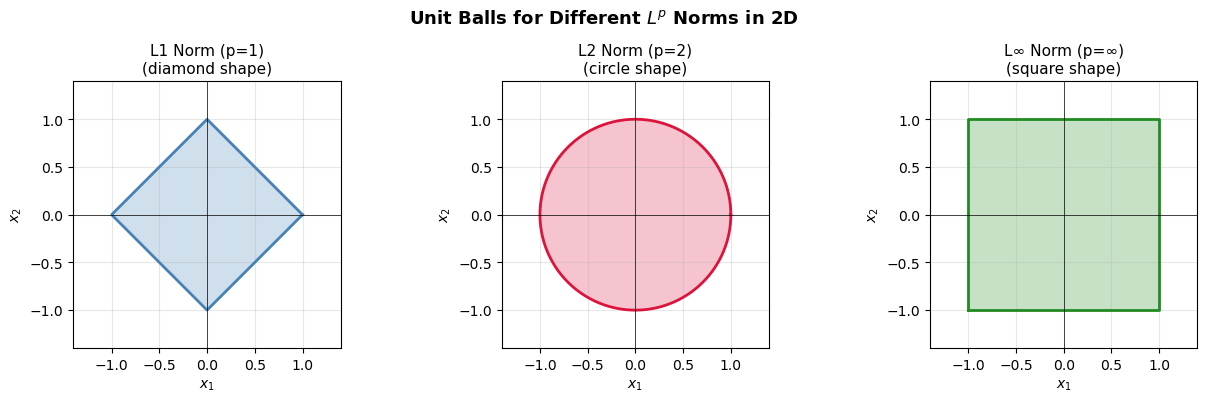

As p increases from 1 to inf, the unit ball expands from a diamond to a circle to a square.


In [2]:
# DEMO: Unit balls for L1, L2, and L-infinity norms in 2D
# The "unit ball" is the set of all points x such that ||x||_p <= 1.

theta = np.linspace(0, 2 * np.pi, 1000)

# For Lp, we parameterise the unit circle implicitly.
# |cos(t)|^p + |sin(t)|^p = 1  =>  r(t) = 1 / (|cos(t)|^p + |sin(t)|^p)^(1/p)
def lp_unit_ball(p, n_points=1000):
    t = np.linspace(0, 2 * np.pi, n_points)
    if np.isinf(p):
        corners = np.array([[-1,-1],[1,-1],[1,1],[-1,1],[-1,-1]])
        return corners[:,0], corners[:,1]
    cos_t = np.cos(t)
    sin_t = np.sin(t)
    denom = (np.abs(cos_t)**p + np.abs(sin_t)**p) ** (1.0/p)
    r = 1.0 / denom
    return r * cos_t, r * sin_t

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
configs = [
    (1,      'L1 Norm (p=1)',    'steelblue',   'diamond shape'),
    (2,      'L2 Norm (p=2)',    'crimson',      'circle shape'),
    (np.inf, 'L∞ Norm (p=∞)', 'forestgreen', 'square shape'),
]

for ax, (p, title, color, desc) in zip(axes, configs):
    x, y = lp_unit_ball(p)
    ax.fill(x, y, alpha=0.25, color=color)
    ax.plot(x, y, color=color, linewidth=2)
    ax.set_xlim(-1.4, 1.4)
    ax.set_ylim(-1.4, 1.4)
    ax.set_aspect('equal')
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_title(f'{title}\n({desc})', fontsize=11)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.grid(True, alpha=0.3)

fig.suptitle('Unit Balls for Different $L^p$ Norms in 2D', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('As p increases from 1 to inf, the unit ball expands from a diamond to a circle to a square.')

### Exercise 1 (Basic): Implement $L^p$ Norm from Scratch

Implement `lp_norm(x, p)` that computes the $L^p$ norm of a vector `x` for any $p \geq 1$, including $p = \infty$.

$$\|\mathbf{x}\|_p = \begin{cases} \left(\sum_i |x_i|^p\right)^{1/p} & p < \infty \\ \max_i |x_i| & p = \infty \end{cases}$$

In [3]:
def lp_norm(x, p):
    """
    Compute the Lp norm of vector x.

    Parameters
    ----------
    x : array-like, 1-D
    p : float, p >= 1 or np.inf

    Returns
    -------
    float : the Lp norm
    """
    x = np.asarray(x, dtype=float)
    if p == np.inf:
        return np.max(np.abs(x))
    return np.sum(np.abs(x) ** p) ** (1.0 / p)


# --- Verification ---
x_test = np.array([3.0, -4.0, 0.0, 1.0])

print('Verification against np.linalg.norm:')
print(f'  p=1  : yours={lp_norm(x_test, 1):.6f}  numpy={np.linalg.norm(x_test, 1):.6f}')
print(f'  p=2  : yours={lp_norm(x_test, 2):.6f}  numpy={np.linalg.norm(x_test, 2):.6f}')
print(f'  p=3  : yours={lp_norm(x_test, 3):.6f}  numpy={np.linalg.norm(x_test, 3):.6f}')
print(f'  p=inf: yours={lp_norm(x_test, np.inf):.6f}  numpy={np.linalg.norm(x_test, np.inf):.6f}')

for p in [1, 2, 3, np.inf]:
    assert np.isclose(lp_norm(x_test, p), np.linalg.norm(x_test, p)), f'Mismatch at p={p}'
print('\nAll assertions passed!')

Verification against np.linalg.norm:
  p=1  : yours=8.000000  numpy=8.000000
  p=2  : yours=5.099020  numpy=5.099020
  p=3  : yours=4.514357  numpy=4.514357
  p=inf: yours=4.000000  numpy=4.000000

All assertions passed!


### Exercise 2 (Basic): Frobenius Norm

The **Frobenius norm** of a matrix is analogous to the Euclidean norm of a vector:
$$\|A\|_F = \sqrt{\sum_{i,j} A_{ij}^2}$$

It also satisfies two equivalent formulations:
$$\|A\|_F = \sqrt{\mathrm{tr}(A^\top A)} = \sqrt{\sum_i \sigma_i^2}$$
where $\sigma_i$ are the singular values of $A$.

In [4]:
def frobenius_norm(A):
    """
    Compute the Frobenius norm of matrix A directly from its elements.

    Parameters
    ----------
    A : 2-D array-like

    Returns
    -------
    float : Frobenius norm
    """
    A = np.asarray(A, dtype=float)
    return np.sqrt(np.sum(A ** 2))


def frobenius_via_trace(A):
    """
    Compute the Frobenius norm using sqrt(trace(A^T A)).

    Returns
    -------
    float : Frobenius norm
    """
    A = np.asarray(A, dtype=float)
    return np.sqrt(np.trace(A.T @ A))


def frobenius_via_svd(A):
    """
    Compute the Frobenius norm as sqrt(sum of squared singular values).

    Returns
    -------
    float : Frobenius norm
    """
    A = np.asarray(A, dtype=float)
    sigma = np.linalg.svd(A, compute_uv=False)
    return np.sqrt(np.sum(sigma ** 2))


# --- Verification ---
A_test = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]], dtype=float)

ref = np.linalg.norm(A_test, 'fro')
f1  = frobenius_norm(A_test)
f2  = frobenius_via_trace(A_test)
f3  = frobenius_via_svd(A_test)

print(f'numpy  reference : {ref:.8f}')
print(f'direct elements  : {f1:.8f}')
print(f'via trace(A^T A) : {f2:.8f}')
print(f'via SVD sigmas   : {f3:.8f}')

assert np.isclose(f1, ref), 'frobenius_norm mismatch'
assert np.isclose(f2, ref), 'frobenius_via_trace mismatch'
assert np.isclose(f3, ref), 'frobenius_via_svd mismatch'
print('\nAll three methods agree!')

numpy  reference : 16.88194302
direct elements  : 16.88194302
via trace(A^T A) : 16.88194302
via SVD sigmas   : 16.88194302

All three methods agree!


### Exercise 3 (Intermediate): Max Norm and Spectral Norm

Two important matrix norms:

- **Max norm** (element-wise $L^\infty$): $\|A\|_{\max} = \max_{i,j} |A_{ij}|$
- **Spectral norm** (induced $L^2$ norm): $\|A\|_2 = \sigma_{\max}(A)$ (largest singular value)

The spectral norm measures how much a matrix can stretch a unit vector — it is the maximum gain of the linear map $\mathbf{x} \mapsto A\mathbf{x}$.

In [5]:
def max_norm(A):
    """
    Compute the max norm: max over all elements of |A_ij|.

    Returns
    -------
    float
    """
    A = np.asarray(A, dtype=float)
    return np.max(np.abs(A))


def spectral_norm(A):
    """
    Compute the spectral norm: largest singular value of A.

    Returns
    -------
    float
    """
    A = np.asarray(A, dtype=float)
    return np.max(np.linalg.svd(A, compute_uv=False))


# --- Comparison on several matrices ---
matrices = {
    'Identity (3x3)':       np.eye(3),
    'Scaling (diag 1,2,5)': np.diag([1., 2., 5.]),
    'Random (4x4)':         np.random.randn(4, 4),
    'Rank-1 outer product': np.outer([1,2,3,4], [1,1,1,1]).astype(float),
}

print(f'{"Matrix":<28}  {"Max norm":>10}  {"Spectral norm":>14}  {"Frobenius":>12}')
print('-' * 70)
for name, M in matrices.items():
    mn = max_norm(M)
    sn = spectral_norm(M)
    fn = np.linalg.norm(M, 'fro')
    print(f'{name:<28}  {mn:>10.4f}  {sn:>14.4f}  {fn:>12.4f}')

# Verify with numpy for the random matrix
R = matrices['Random (4x4)']
assert np.isclose(spectral_norm(R), np.linalg.norm(R, 2)), 'spectral_norm mismatch'
assert np.isclose(max_norm(R), np.max(np.abs(R))),         'max_norm mismatch'
print('\nAssertions passed!')

Matrix                          Max norm   Spectral norm     Frobenius
----------------------------------------------------------------------
Identity (3x3)                    1.0000          1.0000        1.7321
Scaling (diag 1,2,5)              5.0000          5.0000        5.4772
Random (4x4)                      1.9133          3.0796        3.7623
Rank-1 outer product              4.0000         10.9545       10.9545

Assertions passed!


### Exercise 4 (Intermediate): L1 vs L2 Regularization and Sparsity

**Key insight from Goodfellow §2.5:** The $L^1$ norm is frequently used in ML because it promotes *sparsity* — the regularized solution tends to have many components exactly equal to zero. The $L^2$ norm (weight decay) shrinks all weights uniformly but rarely zeroes any of them.

In this exercise you will visualize **regularization paths**: how the coefficient vector changes as the regularization strength $\lambda$ increases from 0 to a large value.

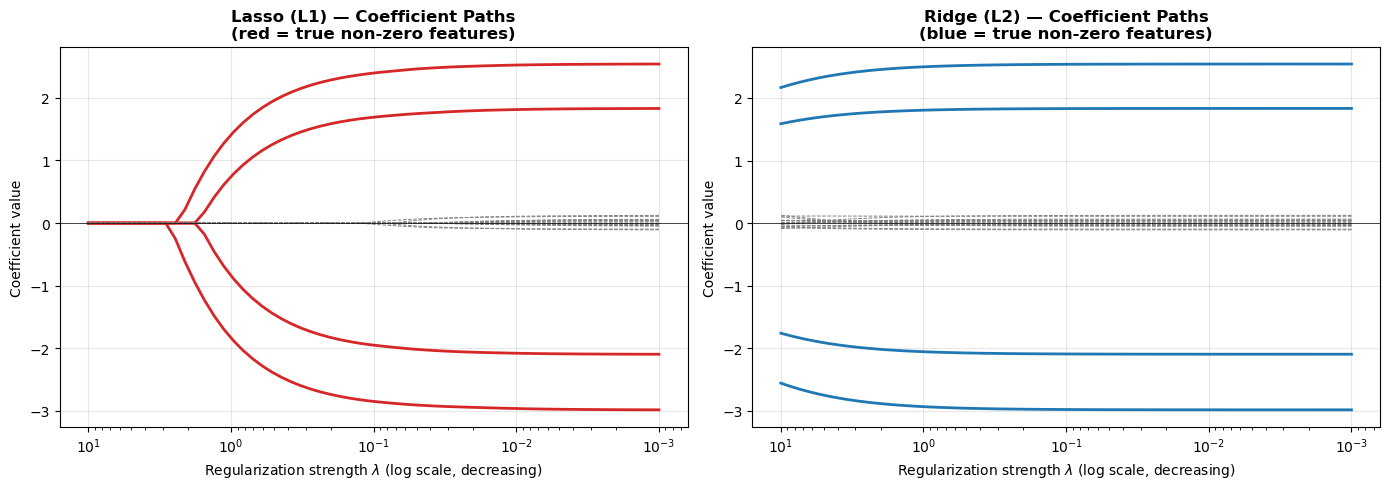

At lambda=0.108:
  Lasso: 14/20 coefficients ~zero  (sparsity=70%)
  Ridge: 0/20 coefficients ~zero  (sparsity=0%)
L1 promotes sparsity; L2 shrinks all coefficients smoothly.


In [6]:
# We use sklearn's Lasso and Ridge purely as solvers to demonstrate the effect;
# the focus is on understanding the regularization paths.
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import StandardScaler

# ---------- Generate synthetic sparse data ----------
n_samples, n_features = 80, 20
np.random.seed(0)

X = np.random.randn(n_samples, n_features)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# True weight vector: only 4 out of 20 features are non-zero (sparse ground truth)
w_true = np.zeros(n_features)
w_true[[0, 3, 7, 14]] = [2.5, -3.0, 1.8, -2.0]

y = X @ w_true + 0.5 * np.random.randn(n_samples)

# 1. Create a range of alpha (lambda) values
alphas = np.logspace(-3, 1, 60)

# 2. For each alpha, fit Lasso and Ridge and store coefficients
lasso_coefs = np.zeros((len(alphas), n_features))
ridge_coefs  = np.zeros((len(alphas), n_features))

for idx, alpha in enumerate(alphas):
    lasso_coefs[idx] = Lasso(alpha=alpha, max_iter=10000).fit(X, y).coef_
    ridge_coefs[idx]  = Ridge(alpha=alpha).fit(X, y).coef_


# ---------- Visualize coefficient paths ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Lasso paths
ax = axes[0]
for j in range(n_features):
    style = '-' if j in [0, 3, 7, 14] else '--'
    lw    = 2.0 if j in [0, 3, 7, 14] else 0.7
    color = 'tab:red' if j in [0, 3, 7, 14] else 'gray'
    ax.plot(alphas, lasso_coefs[:, j], style, linewidth=lw, color=color)
ax.set_xscale('log')
ax.invert_xaxis()
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('Regularization strength $\\lambda$ (log scale, decreasing)')
ax.set_ylabel('Coefficient value')
ax.set_title('Lasso (L1) — Coefficient Paths\n(red = true non-zero features)', fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot Ridge paths
ax = axes[1]
for j in range(n_features):
    style = '-' if j in [0, 3, 7, 14] else '--'
    lw    = 2.0 if j in [0, 3, 7, 14] else 0.7
    color = 'tab:blue' if j in [0, 3, 7, 14] else 'gray'
    ax.plot(alphas, ridge_coefs[:, j], style, linewidth=lw, color=color)
ax.set_xscale('log')
ax.invert_xaxis()
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('Regularization strength $\\lambda$ (log scale, decreasing)')
ax.set_ylabel('Coefficient value')
ax.set_title('Ridge (L2) — Coefficient Paths\n(blue = true non-zero features)', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show sparsity at a fixed lambda
mid_alpha = alphas[30]
lasso_mid = Lasso(alpha=mid_alpha, max_iter=10000).fit(X, y)
ridge_mid = Ridge(alpha=mid_alpha).fit(X, y)
lasso_zeros = np.sum(np.abs(lasso_mid.coef_) < 1e-3)
ridge_zeros = np.sum(np.abs(ridge_mid.coef_) < 1e-3)
print(f'At lambda={mid_alpha:.3f}:')
print(f'  Lasso: {lasso_zeros}/{n_features} coefficients ~zero  (sparsity={lasso_zeros/n_features:.0%})')
print(f'  Ridge: {ridge_zeros}/{n_features} coefficients ~zero  (sparsity={ridge_zeros/n_features:.0%})')
print('L1 promotes sparsity; L2 shrinks all coefficients smoothly.')

---
## Part 2: Special Kinds of Matrices and Vectors (Section 2.6)

Goodfellow §2.6 covers matrices with useful structure:

| Type | Definition | Key property |
|------|-----------|-------------|
| Diagonal | $D_{ij} = 0$ for $i \neq j$ | Cheap multiply / invert |
| Symmetric | $A = A^\top$ | Real eigenvalues |
| Orthogonal | $Q^\top Q = I$ | Norm-preserving; $Q^{-1} = Q^\top$ |
| PD / PSD | $\mathbf{x}^\top A \mathbf{x} > 0$ (or $\geq 0$) | Stable Cholesky; valid covariance |

2D rotation by 37 degrees:
[[ 0.79863551 -0.60181502]
 [ 0.60181502  0.79863551]]

Verification of orthogonality properties:
  Q^T Q (should be I):
[[1. 0.]
 [0. 1.]]
  det(Q) = 1.000000  (should be +1 for proper rotation)

  ||v||_2     = 5.000000
  ||Q v||_2   = 5.000000  (preserved)


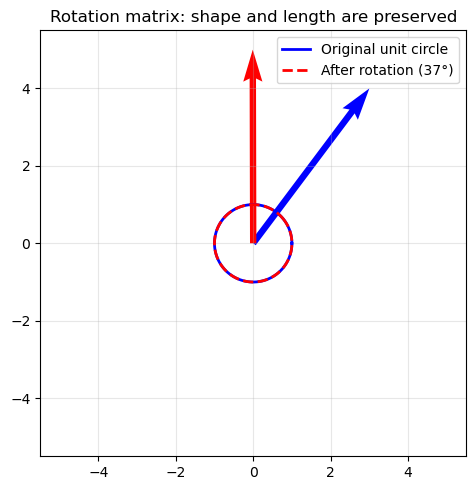

In [7]:
# DEMO: Orthogonal / rotation matrix properties
# A 2D rotation by angle theta is the canonical example of an orthogonal matrix.

def rotation_matrix_2d(theta_deg):
    t = np.radians(theta_deg)
    return np.array([[np.cos(t), -np.sin(t)],
                     [np.sin(t),  np.cos(t)]])

Q = rotation_matrix_2d(37)   # arbitrary angle

print('2D rotation by 37 degrees:')
print(Q)

print('\nVerification of orthogonality properties:')
print(f'  Q^T Q (should be I):\n{Q.T @ Q}')
print(f'  det(Q) = {np.linalg.det(Q):.6f}  (should be +1 for proper rotation)')

# Norms are preserved
v = np.array([3.0, 4.0])
Qv = Q @ v
print(f'\n  ||v||_2     = {np.linalg.norm(v):.6f}')
print(f'  ||Q v||_2   = {np.linalg.norm(Qv):.6f}  (preserved)')

# Visualise rotation
angles = np.linspace(0, 2*np.pi, 200)
circle = np.vstack([np.cos(angles), np.sin(angles)])
rotated = Q @ circle

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(circle[0], circle[1], 'b-', lw=2, label='Original unit circle')
ax.plot(rotated[0], rotated[1], 'r--', lw=2, label='After rotation (37°)')
ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='blue',   width=0.015)
ax.quiver(0, 0, Qv[0], Qv[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.015)
ax.set_xlim(-5.5, 5.5); ax.set_ylim(-5.5, 5.5)
ax.set_aspect('equal')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_title('Rotation matrix: shape and length are preserved')
plt.tight_layout(); plt.show()

### Exercise 5 (Basic): Efficient Diagonal Matrix Operations

For a diagonal matrix $D = \mathrm{diag}(d_1, \ldots, d_n)$:
- $D\mathbf{x}$ can be computed as element-wise product: $d \odot x$ — **O(n)** instead of **O(n²)**
- $D^{-1}\mathbf{x}$ is simply $\mathbf{x} / d$ (assuming no zeros)
- $D^k\mathbf{x}$ is $d^k \odot x$ (element-wise power)

This matters at scale — never form the full $n\times n$ matrix when you only need the diagonal.

In [8]:
def diag_matvec(d, x):
    """
    Compute D @ x efficiently using only the diagonal vector d.
    Do NOT form the full matrix np.diag(d).

    Parameters
    ----------
    d : 1-D array, diagonal entries
    x : 1-D array, vector to multiply

    Returns
    -------
    1-D array : D @ x
    """
    return d * x


def diag_inv_matvec(d, x):
    """
    Compute D^{-1} @ x efficiently (assume all d_i != 0).

    Returns
    -------
    1-D array : D^{-1} @ x
    """
    return x / d


def diag_pow_matvec(d, x, k):
    """
    Compute D^k @ x efficiently for integer k.

    Returns
    -------
    1-D array : D^k @ x
    """
    return (d ** k) * x


# --- Correctness verification ---
d = np.array([1., 2., 3., 4.])
x = np.array([1., -1., 2., -2.])
D = np.diag(d)

assert np.allclose(diag_matvec(d, x),     D @ x),             'diag_matvec failed'
assert np.allclose(diag_inv_matvec(d, x), np.linalg.inv(D) @ x), 'diag_inv_matvec failed'
assert np.allclose(diag_pow_matvec(d, x, 3), np.linalg.matrix_power(D, 3) @ x), 'diag_pow_matvec failed'
print('Correctness checks passed.\n')

# --- Timing comparison ---
n = 5000
d_big = np.random.rand(n) + 0.1
x_big = np.random.randn(n)
D_big = np.diag(d_big)   # full matrix (only for naive timing)

reps = 200
t0 = time.perf_counter()
for _ in range(reps):
    _ = diag_matvec(d_big, x_big)
t_efficient = (time.perf_counter() - t0) / reps * 1e6

t0 = time.perf_counter()
for _ in range(reps):
    _ = D_big @ x_big
t_naive = (time.perf_counter() - t0) / reps * 1e6

print(f'n = {n:,}  (average over {reps} reps):')
print(f'  Efficient diag_matvec : {t_efficient:7.2f} µs')
print(f'  Naive full matrix mul  : {t_naive:7.2f} µs')
print(f'  Speedup                : {t_naive/t_efficient:.1f}x')

Correctness checks passed.

n = 5,000  (average over 200 reps):
  Efficient diag_matvec :    2.74 µs
  Naive full matrix mul  : 5320.44 µs
  Speedup                : 1943.0x


### Exercise 6 (Basic): Symmetric and Anti-Symmetric Decomposition

Every square matrix $A$ can be uniquely decomposed as:
$$A = \underbrace{\frac{A + A^\top}{2}}_{\text{symmetric part}} + \underbrace{\frac{A - A^\top}{2}}_{\text{anti-symmetric part}}$$

where the symmetric part $S$ satisfies $S = S^\top$ and the anti-symmetric part $K$ satisfies $K = -K^\top$ (so diagonal entries of $K$ are zero).

In [9]:
def is_symmetric(A, tol=1e-10):
    """
    Return True if A is symmetric (A == A^T) within tolerance tol.

    Parameters
    ----------
    A   : 2-D square array
    tol : float

    Returns
    -------
    bool
    """
    A = np.asarray(A, dtype=float)
    return np.allclose(A, A.T, atol=tol)


def symmetric_part(A):
    """
    Return the symmetric part of square matrix A: (A + A^T) / 2.

    Returns
    -------
    2-D array
    """
    A = np.asarray(A, dtype=float)
    return (A + A.T) / 2


def antisymmetric_part(A):
    """
    Return the anti-symmetric part of square matrix A: (A - A^T) / 2.

    Returns
    -------
    2-D array
    """
    A = np.asarray(A, dtype=float)
    return (A - A.T) / 2


# --- Verification ---
A_test = np.array([[4, 2, 7],
                   [1, 5, 3],
                   [8, 6, 9]], dtype=float)

S = symmetric_part(A_test)
K = antisymmetric_part(A_test)

print('Original A:')
print(A_test)
print('\nSymmetric part S:')
print(S)
print('\nAnti-symmetric part K:')
print(K)
print('\nS + K (should equal A):')
print(S + K)

assert is_symmetric(S),               'S should be symmetric'
assert np.allclose(K, -K.T),          'K should be anti-symmetric (K = -K^T)'
assert np.allclose(S + K, A_test),    'S + K should reconstruct A'
assert not is_symmetric(A_test),      'A_test is not symmetric'
assert is_symmetric(A_test + A_test.T), 'A + A^T should be symmetric'
print('\nAll assertions passed!')

Original A:
[[4. 2. 7.]
 [1. 5. 3.]
 [8. 6. 9.]]

Symmetric part S:
[[4.  1.5 7.5]
 [1.5 5.  4.5]
 [7.5 4.5 9. ]]

Anti-symmetric part K:
[[ 0.   0.5 -0.5]
 [-0.5  0.  -1.5]
 [ 0.5  1.5  0. ]]

S + K (should equal A):
[[4. 2. 7.]
 [1. 5. 3.]
 [8. 6. 9.]]

All assertions passed!


### Exercise 7 (Intermediate): Positive Definiteness — Three Tests

A symmetric matrix $A$ is **positive definite (PD)** if $\mathbf{x}^\top A \mathbf{x} > 0$ for all $\mathbf{x} \neq 0$.

Equivalent tests:
1. **Eigenvalue test:** All eigenvalues $\lambda_i > 0$
2. **Cholesky test:** Cholesky decomposition $A = LL^\top$ succeeds (no negative pivots)
3. **Sylvester's criterion:** All leading principal minors are positive ($\det(A_{1:k,1:k}) > 0$ for $k = 1,\ldots,n$)

In [10]:
def is_pd_eigenvalue(A):
    """
    Test PD via eigenvalues: return True iff all eigenvalues of A are > 0.
    Assume A is symmetric.

    Returns
    -------
    bool
    """
    A = np.asarray(A, dtype=float)
    eigenvalues = np.linalg.eigvalsh(A)
    return bool(np.all(eigenvalues > 0))


def is_pd_cholesky(A):
    """
    Test PD via Cholesky decomposition: return True iff np.linalg.cholesky(A) succeeds.

    Returns
    -------
    bool
    """
    A = np.asarray(A, dtype=float)
    try:
        np.linalg.cholesky(A)
        return True
    except np.linalg.LinAlgError:
        return False


def is_pd_sylvester(A):
    """
    Test PD via Sylvester's criterion: return True iff all leading principal
    minors (det of top-left k x k submatrix for k=1..n) are positive.

    Returns
    -------
    bool
    """
    A = np.asarray(A, dtype=float)
    n = A.shape[0]
    for k in range(1, n + 1):
        if np.linalg.det(A[:k, :k]) <= 0:
            return False
    return True


# --- Test matrices ---
# 1. PD: A^T A + eps*I for random A guarantees PD
B = np.random.randn(4, 4)
A_pd  = B.T @ B + 3 * np.eye(4)

# 2. PSD but not PD: outer product has zero eigenvalue
v = np.array([1., 2., 3., 4.])
A_psd = np.outer(v, v) + np.eye(4) * 0.0   # rank-1, eigenvalues 0,0,0,||v||^2
A_psd = np.outer(v, v)                       # purely rank-1: PSD

# 3. Indefinite: has both positive and negative eigenvalues
A_indef = np.array([[2., 3.],
                    [3., 1.]])

print(f'{"Matrix":<18}  {"Eigenvalue":>12}  {"Cholesky":>10}  {"Sylvester":>10}')
print('-' * 57)
for name, M in [('PD',A_pd), ('PSD (rank-1)',A_psd), ('Indefinite',A_indef)]:
    e = is_pd_eigenvalue(M)
    c = is_pd_cholesky(M)
    s = is_pd_sylvester(M)
    print(f'{name:<18}  {str(e):>12}  {str(c):>10}  {str(s):>10}')

# All three tests should agree on the PD matrix
assert is_pd_eigenvalue(A_pd) and is_pd_cholesky(A_pd) and is_pd_sylvester(A_pd), \
    'All three should return True for PD matrix'
assert not is_pd_eigenvalue(A_psd),  'PSD (not PD) should fail eigenvalue test'
assert not is_pd_eigenvalue(A_indef),'Indefinite should fail eigenvalue test'
print('\nAll assertions passed!')

Matrix                Eigenvalue    Cholesky   Sylvester
---------------------------------------------------------
PD                          True        True        True
PSD (rank-1)               False       False       False
Indefinite                 False       False       False

All assertions passed!


### Exercise 8 (Challenging): Gram-Schmidt Orthogonalization

Given a set of linearly independent vectors $\{\mathbf{v}_1, \ldots, \mathbf{v}_k\}$, the **Gram-Schmidt** process produces an orthonormal basis $\{\mathbf{q}_1, \ldots, \mathbf{q}_k\}$ spanning the same subspace:

$$\mathbf{u}_j = \mathbf{v}_j - \sum_{i=1}^{j-1} \langle \mathbf{v}_j, \mathbf{q}_i \rangle \mathbf{q}_i, \qquad \mathbf{q}_j = \frac{\mathbf{u}_j}{\|\mathbf{u}_j\|}$$

This gives the thin QR decomposition: $V = QR$ where $Q^\top Q = I$.

Q^T Q (should be identity):
[[ 1. -0. -0.]
 [-0.  1.  0.]
 [-0.  0.  1.]]
Q^T Q = I verified.

numpy qr column norms  : [1. 1. 1.]
gram_schmidt col norms : [1. 1. 1.]
Columns match numpy QR (up to sign).



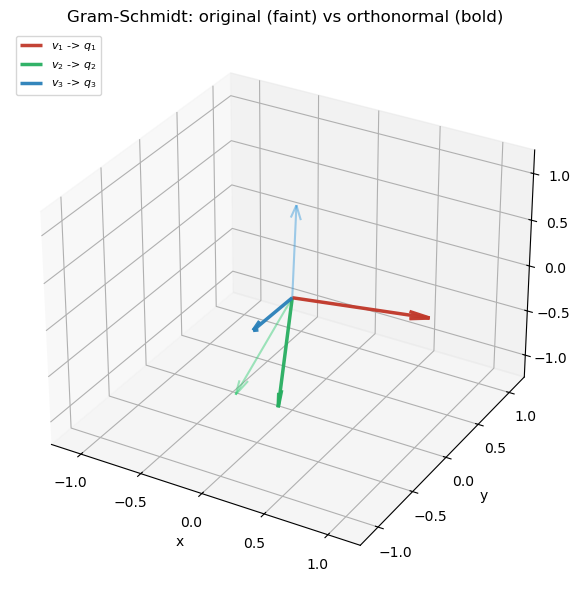

In [11]:
def gram_schmidt(V):
    """
    Perform Gram-Schmidt orthogonalization on the columns of V.

    Parameters
    ----------
    V : 2-D array of shape (n, k), columns are the input vectors.
        Assumes columns are linearly independent.

    Returns
    -------
    Q : 2-D array of shape (n, k), columns are orthonormal vectors.
    """
    V = np.asarray(V, dtype=float)
    n, k = V.shape
    Q = np.zeros_like(V, dtype=float)
    for j in range(k):
        # Start with j-th input column
        q = V[:, j].copy().astype(float)
        # Subtract projections onto previously computed orthonormal vectors
        for i in range(j):
            q -= np.dot(Q[:, i], q) * Q[:, i]
        # Normalise to unit length
        Q[:, j] = q / np.linalg.norm(q)
    return Q


# --- Verification in 3D ---
np.random.seed(7)
V3 = np.random.randn(3, 3)    # 3 random vectors in R^3
Q3 = gram_schmidt(V3)

print('Q^T Q (should be identity):')
print(np.round(Q3.T @ Q3, 10))

assert np.allclose(Q3.T @ Q3, np.eye(3), atol=1e-10), 'Q^T Q != I'
print('Q^T Q = I verified.\n')

# Compare with numpy's QR decomposition (signs may differ column-wise)
Q_np, R_np = np.linalg.qr(V3)
print('numpy qr column norms  :', np.linalg.norm(Q_np, axis=0))
print('gram_schmidt col norms :', np.linalg.norm(Q3,   axis=0))

# Both should span the same column space (columns match up to sign)
for j in range(3):
    dot = abs(Q3[:, j] @ Q_np[:, j])
    assert np.isclose(dot, 1.0, atol=1e-8), f'Column {j} mismatch vs numpy QR'
print('Columns match numpy QR (up to sign).\n')

# --- 3D Visualisation ---
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

colors_orig  = ['#e74c3c', '#2ecc71', '#3498db']
colors_ortho = ['#c0392b', '#27ae60', '#2980b9']
labels_orig  = ['$v_1$', '$v_2$', '$v_3$']
labels_q     = ['$q_1$', '$q_2$', '$q_3$']

origin = np.zeros(3)
for j in range(3):
    v = V3[:, j] / np.linalg.norm(V3[:, j])   # normalised for visual
    q = Q3[:, j]
    ax.quiver(*origin, *v, color=colors_orig[j],  alpha=0.45, linewidth=1.5, arrow_length_ratio=0.15)
    ax.quiver(*origin, *q, color=colors_ortho[j], alpha=0.95, linewidth=2.5, arrow_length_ratio=0.15,
              label=f'{labels_orig[j]} -> {labels_q[j]}')

ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2); ax.set_zlim(-1.2, 1.2)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Gram-Schmidt: original (faint) vs orthonormal (bold)')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

### Exercise 9 (Challenging): Rodrigues' Rotation Formula

Given a unit axis $\hat{\mathbf{k}}$ and angle $\theta$, the **Rodrigues' formula** constructs the 3D rotation matrix:

$$R = I\cos\theta + \sin\theta [\hat{\mathbf{k}}]_\times + (1-\cos\theta)\, \hat{\mathbf{k}}\hat{\mathbf{k}}^\top$$

where $[\hat{\mathbf{k}}]_\times$ is the skew-symmetric cross-product matrix:
$$[\mathbf{k}]_\times = \begin{pmatrix} 0 & -k_z & k_y \\ k_z & 0 & -k_x \\ -k_y & k_x & 0 \end{pmatrix}$$

Any 3D rotation matrix is orthogonal with $\det(R) = +1$.

R_z(90) @ [1,0,0] (should be [0,1,0]): [0. 1. 0.]
Orthogonality and det=+1 verified for all test angles.



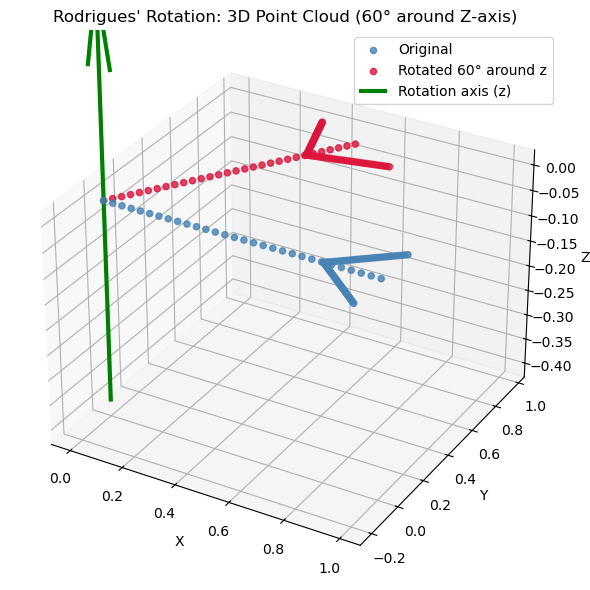

Rotation matrix R_z(60):
[[ 0.5   -0.866  0.   ]
 [ 0.866  0.5    0.   ]
 [ 0.     0.     1.   ]]


In [12]:
def skew_symmetric(k):
    """
    Return the 3x3 skew-symmetric (cross-product) matrix of vector k.

    Parameters
    ----------
    k : array of shape (3,)

    Returns
    -------
    3x3 array K such that K @ v == np.cross(k, v) for any v
    """
    k = np.asarray(k, dtype=float)
    return np.array([[ 0,      -k[2],  k[1]],
                     [ k[2],   0,     -k[0]],
                     [-k[1],   k[0],   0   ]])


def rodrigues_rotation(axis, theta_deg):
    """
    Construct a 3D rotation matrix via Rodrigues' formula.

    Parameters
    ----------
    axis      : array of shape (3,), rotation axis (need not be unit)
    theta_deg : float, rotation angle in degrees

    Returns
    -------
    R : 3x3 rotation matrix
    """
    axis = np.asarray(axis, dtype=float)
    # 1. Normalise axis to unit vector
    axis = axis / np.linalg.norm(axis)
    # 2. Build skew-symmetric matrix K
    K = skew_symmetric(axis)
    # 3. Convert angle to radians
    theta = np.radians(theta_deg)
    # 4. Rodrigues' formula
    R = np.eye(3) * np.cos(theta) + np.sin(theta) * K + (1 - np.cos(theta)) * np.outer(axis, axis)
    return R


# --- Verification ---
# Rotation by 90 degrees around z-axis: maps x -> y
R_z90 = rodrigues_rotation([0, 0, 1], 90)
x_hat = np.array([1., 0., 0.])
y_hat = np.array([0., 1., 0.])
print('R_z(90) @ [1,0,0] (should be [0,1,0]):', np.round(R_z90 @ x_hat, 8))
assert np.allclose(R_z90 @ x_hat, y_hat, atol=1e-10), 'z-axis rotation failed'

# General rotation: check orthogonality and det=1
axis_test = [1., 2., 3.]
for angle in [0, 30, 90, 137, 270]:
    R = rodrigues_rotation(axis_test, angle)
    assert np.allclose(R.T @ R, np.eye(3), atol=1e-10), f'Not orthogonal at {angle}°'
    assert np.isclose(np.linalg.det(R), 1.0,  atol=1e-10), f'det != 1 at {angle}°'
print('Orthogonality and det=+1 verified for all test angles.\n')

# --- Rotate a point cloud and visualise ---
np.random.seed(3)
# Create a point cloud shaped like a simple arrow/arrow-head in 3D
t_line = np.linspace(0, 1, 30)
shaft  = np.column_stack([t_line, np.zeros(30), np.zeros(30)])
tip_u  = np.column_stack([0.8 + 0.2*t_line, 0.2*t_line, np.zeros(30)])
tip_d  = np.column_stack([0.8 + 0.2*t_line, -0.2*t_line, np.zeros(30)])
cloud  = np.vstack([shaft, tip_u, tip_d])   # shape (90, 3)

R_final = rodrigues_rotation([0, 0, 1], 60)   # 60 deg around z
cloud_rotated = (R_final @ cloud.T).T

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(cloud[:, 0],         cloud[:, 1],         cloud[:, 2],
           c='steelblue', s=20, label='Original', alpha=0.8)
ax.scatter(cloud_rotated[:, 0], cloud_rotated[:, 1], cloud_rotated[:, 2],
           c='crimson',   s=20, label='Rotated 60° around z', alpha=0.8)

# Draw rotation axis
ax.quiver(0, 0, -0.4, 0, 0, 0.8, color='green', linewidth=3,
          arrow_length_ratio=0.2, label='Rotation axis (z)')

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title("Rodrigues' Rotation: 3D Point Cloud (60° around Z-axis)")
ax.legend()
plt.tight_layout()
plt.show()
print(f'Rotation matrix R_z(60):\n{np.round(R_final, 4)}')

---
## Summary

### Part 1: Norms (Section 2.5)

| Norm | Formula | Key use in ML |
|------|---------|---------------|
| $L^1$ | $\sum_i |x_i|$ | Sparsity-promoting regularization (Lasso) |
| $L^2$ | $\sqrt{\sum_i x_i^2}$ | Weight decay; natural distance |
| $L^\infty$ | $\max_i |x_i|$ | Robustness; adversarial bounds |
| Frobenius | $\sqrt{\sum_{ij} A_{ij}^2}$ | Matrix regularization; low-rank approx |
| Spectral | $\sigma_{\max}(A)$ | Lipschitz constant of linear map |

**Key insight:** $L^1$ regularization promotes *exact zeros* (sparsity) while $L^2$ shrinks all weights uniformly.

### Part 2: Special Matrices (Section 2.6)

| Structure | Property | Why it matters |
|-----------|----------|----------------|
| Diagonal | $D_{ij}=0, i\neq j$ | $O(n)$ multiply/invert instead of $O(n^2)$ |
| Symmetric | $A = A^\top$ | Real eigenvalues; covariance matrices |
| Orthogonal | $Q^\top Q = I$ | Norm-preserving; $Q^{-1} = Q^\top$ (cheap) |
| PD / PSD | $\mathbf{x}^\top A\mathbf{x} > 0$ | Valid covariance, stable optimization |

**Gram-Schmidt** shows how to build orthogonal bases (the foundation of QR decomposition and many solvers). **Rodrigues' formula** shows that 3D rotations form the group $SO(3)$ — a cornerstone of robotics, graphics, and geometric deep learning.